# Object Detection with YOLO

**Goal**: Detecting objects within images.

**Objectives**:

- Detect objects in an image using the YOLO model.

- Parse the results from running the YOLO model.

- Display the resulting bounding boxes from running the YOLO model.

- Detect objects from a variety of sources, including videos and images stoored in directories. 

- Detect objects from a video source. 

In [15]:
import sys
from collections import Counter
from pathlib import Path

import PIL
import torch
import torchvision
import ultralytics
from IPython.display import Video
from PIL import Image
from torchvision import transforms
from torchvision.io import read_image
from torchvision.utils import make_grid
from ultralytics import YOLO

In [16]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("PIL version : ", PIL.__version__)
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)
print("ultralytics version : ", ultralytics.__version__)

Platform: win32
Python version: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
---
PIL version :  10.2.0
torch version :  2.5.1+cpu
torchvision version :  0.20.1+cpu
ultralytics version :  8.3.99


- We use the YOLO version 8 pretrained model from the ```ultralytics``` package.

In [17]:
yolo = YOLO(task='detect', model='yolov8s.pt')

100%|██████████| 21.5M/21.5M [00:19<00:00, 1.17MB/s]


What classes can this pretrained model detect?

In [27]:
#  lists all classes
# yolo.names 

# For example lets see what 5 corresponds to:
yolo.names[5]

# and index 23:
class_assigned_to_23 = yolo.names[23]
print(f"{class_assigned_to_23} corresponds to 23")

giraffe corresponds to 23


Classes that we want to detect but are not included in the YOLO model:

In [28]:
classes_not_in_yolo = [
    "ambulance",
    "army vehicle",
    "auto rickshaw",
    "garbagevan",
    "human hauler",
    "minibus",
    "minivan",
    "pickup",
    "policecar",
    "rickshaw",
    "scooter",
    "suv",
    "taxi",
    "three wheelers (CNG)",
    "van",
    "wheelbarrow",
]

Let's double check that "ambulance" is not in the YOLO classes.

In [29]:
"ambulance" not in yolo.names.values()

True

What of 'army vehicle'?

In [30]:
is_army_vehicle_inlcuded = "army vehicle" not in yolo.names.values()
print(is_army_vehicle_inlcuded)

True


We use th YOLO model to identify objects in one frame of our video data. 

In [31]:
data_dir = Path("data_video", "extracted_frames")
image_path = data_dir / "frame_1050.jpg"

result = yolo(image_path)


image 1/1 d:\workspace\applied-ai\0x02-traffic_monitoring_in_bangladesh\data_video\extracted_frames\frame_1050.jpg: 384x640 2 persons, 1 bicycle, 8 cars, 2 buss, 264.3ms
Speed: 4.7ms preprocess, 264.3ms inference, 16.9ms postprocess per image at shape (1, 3, 384, 640)


Results:

In [32]:
print(f"Type of result: {type(result)}")
print(f"Length of result: {len(result)}")

Type of result: <class 'list'>
Length of result: 1


Using the ```.predict``` method with a 50% threshold for bounding box.

In [33]:
result = yolo.predict(image_path, conf=0.5, save=True, save_txt=True)


image 1/1 d:\workspace\applied-ai\0x02-traffic_monitoring_in_bangladesh\data_video\extracted_frames\frame_1050.jpg: 384x640 1 person, 1 bicycle, 3 cars, 2 buss, 207.0ms
Speed: 1.5ms preprocess, 207.0ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs\detect\predict
1 label saved to runs\detect\predict\labels


We can use the predict method for frame_2575.jpg.

In [37]:
image_path_task = Path("data_video", "extracted_frames")
result_task =  yolo(image_path_task / "frame_2575.jpg")

print(type(result_task))


image 1/1 d:\workspace\applied-ai\0x02-traffic_monitoring_in_bangladesh\data_video\extracted_frames\frame_2575.jpg: 384x640 13 persons, 11 cars, 1 motorcycle, 1 truck, 1 backpack, 197.9ms
Speed: 2.5ms preprocess, 197.9ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs\detect\predict
2 labels saved to runs\detect\predict\labels
<class 'list'>


In [ ]:
result_task = yolo.predict(image_path_task, conf=0.5, save=True, save_txt=True)

**Results from Running YOLO**

result[0] contains a special object with the results of the prediction stored as attributes.

In [39]:
result[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

```.boxes``` contains the data for the bounding boxes. These bounding boxes are the main things we want from object detection. These boxes are then used to create a box around the detected objects.

In [40]:
result[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([2., 2., 2., 1., 5., 5., 0.])
conf: tensor([0.9039, 0.8548, 0.8375, 0.8323, 0.8061, 0.6084, 0.5534])
data: tensor([[4.3695e+02, 1.6984e+02, 5.4202e+02, 2.3865e+02, 9.0395e-01, 2.0000e+00],
        [1.5662e+02, 1.5208e+02, 3.2427e+02, 2.5230e+02, 8.5477e-01, 2.0000e+00],
        [5.3971e+02, 1.8355e+02, 6.1373e+02, 2.3000e+02, 8.3751e-01, 2.0000e+00],
        [2.7851e+02, 1.7785e+02, 4.4652e+02, 2.9214e+02, 8.3232e-01, 1.0000e+00],
        [4.6189e-01, 1.0103e+01, 7.6920e+01, 2.1562e+02, 8.0605e-01, 5.0000e+00],
        [5.4849e+02, 1.3676e+02, 6.1407e+02, 1.8558e+02, 6.0838e-01, 5.0000e+00],
        [3.1102e+02, 1.0355e+02, 3.7114e+02, 2.5445e+02, 5.5339e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (360, 640)
shape: torch.Size([7, 6])
xywh: tensor([[489.4863, 204.2482, 105.0627,  68.8101],
        [240.4418, 202.1921, 167.6510, 100.2223],
        [576.7197, 206.7732,  74.0134,  46.4463],
        [362.5140,

The `.cls` attribute contains the classes of each of the objects detected. It's a PyTorch tensor. The length of the tensor is the number of objects detected.

In [41]:
print(result[0].boxes.cls)
print(f"Number of objects detected: {len(result[0].boxes.cls)}")

tensor([2., 2., 2., 1., 5., 5., 0.])
Number of objects detected: 7


Number of detected objects:

In [47]:
number_of_detected_objs = len(result_task[0].boxes.cls)
print(f"Number of objects detected in frame_2575.jpg: {number_of_detected_objs}")

Number of objects detected in frame_2575.jpg: 13


Objects detected:

In [48]:
object_counts = Counter([yolo.names[int(cls)] for cls in result[0].boxes.cls])
object_counts

Counter({'car': 3, 'bus': 2, 'bicycle': 1, 'person': 1})

The most common class and the number of times it was detected in `frame_2575.jpg`

In [49]:
object_counts_task = Counter([yolo.names[int(cls)] for cls in result_task[0].boxes.cls])

most_common_class, count_of_class = object_counts_task.most_common(n=1)[0]
print(f"Most common class: {most_common_class}")
print(f"Number of detected {most_common_class}: {count_of_class}")

Most common class: person
Number of detected person: 6


Another important attribute is `.conf` which has the confidence of the detected bounding boxes. The confidence is stored in a PyTorch tensor.

In [50]:
print(result[0].boxes.conf)
print(f"Number of objects detected: {len(result[0].boxes.conf)}")

tensor([0.9039, 0.8548, 0.8375, 0.8323, 0.8061, 0.6084, 0.5534])
Number of objects detected: 7


In [51]:
length_of_confidence_tensor = len(result_task[0].boxes.conf)
print(f"Number of objects detected: {length_of_confidence_tensor}")

Number of objects detected: 13


When calling `.predict`, we set the confidence threshold to 50%. That is why all values in the confidence tensor is greater than 0.5. How many of the bounding boxes have a confidence value greater than 75%? For frame frame_1050.jpg, that would be:

In [52]:
number_of_confident_objects = (result[0].boxes.conf > 0.75).sum().item()
print(f"Number of objects detected with 50% confidence: {number_of_confident_objects}")

Number of objects detected with 50% confidence: 5


In [54]:
number_of_confident_objects_task = (result_task[0].boxes.conf > 0.75).sum().item()

print(
    f"Number of objects detected in frame_2575.jpg with 50% confidence: {number_of_confident_objects_task}"
)

Number of objects detected in frame_2575.jpg with 50% confidence: 6


*The original Data*

The `.data` attribute contains the raw detection data. 

`.xywh` is a tensor with four columns for each row. Each row represents one box. The first and second column is the x and y coordinates of the top-left corner of the box, respectively. The third and fourth columns are width and height, respectively.

In [55]:
result[0].boxes.xywh

tensor([[489.4863, 204.2482, 105.0627,  68.8101],
        [240.4418, 202.1921, 167.6510, 100.2223],
        [576.7197, 206.7732,  74.0134,  46.4463],
        [362.5140, 234.9969, 168.0120, 114.2923],
        [ 38.6910, 112.8627,  76.4582, 205.5199],
        [581.2806, 161.1671,  65.5864,  48.8183],
        [341.0811, 179.0009,  60.1201, 150.9053]])

`.xywhn` is very similar to `.xywh` but these coordinates have been normalized by the image size. We can remind ourselves of the original shape with `.orig_shape`.

In [56]:
result[0].orig_shape

(360, 640)

This means the image is 360 pixels high and 640 pixels wide. Let's examine one row of the normalized bounding box.

In [57]:
result[0].boxes.xywhn[0]

tensor([0.7648, 0.5674, 0.1642, 0.1911])

We can use the original shape to verify that indeed .xywhn is normalized.

In [59]:
result[0].boxes.xywh[0] / torch.Tensor([640, 360, 640, 360]).to("cpu")

tensor([0.7648, 0.5674, 0.1642, 0.1911])

Print out the original shape of frame_2575.jpg.

In [60]:
original_shape_task = result_task[0].orig_shape
print(f"Original shape of frame_2574.jpg: {original_shape_task}")

Original shape of frame_2574.jpg: (360, 640)


 Print out the normalized xywh bounding box for the first object of frame_2575.jpg.

In [63]:
normalized_xywh = result_task[0].boxes.xywhn[0]
print(f"Normalized xywh bounding box for frame_2575.jpg: {normalized_xywh[0]}")

Normalized xywh bounding box for frame_2575.jpg: 0.9120184183120728


Normalize using original shape:

In [62]:
normalized_xywh = result_task[0].boxes.xywh[0] / torch.Tensor([640, 360, 640, 360]).to("cpu")
print(f"Normalized xywh bounding box for frame_2575.jpg: {normalized_xywh[0]}")

Normalized xywh bounding box for frame_2575.jpg: 0.9120184183120728


`.xyxy` contains two coordinates, the (x, y) coordinate for the top left corner and the (x, y) coordinate of the bottom right corner.

In [64]:
result[0].boxes.xyxy

tensor([[4.3695e+02, 1.6984e+02, 5.4202e+02, 2.3865e+02],
        [1.5662e+02, 1.5208e+02, 3.2427e+02, 2.5230e+02],
        [5.3971e+02, 1.8355e+02, 6.1373e+02, 2.3000e+02],
        [2.7851e+02, 1.7785e+02, 4.4652e+02, 2.9214e+02],
        [4.6189e-01, 1.0103e+01, 7.6920e+01, 2.1562e+02],
        [5.4849e+02, 1.3676e+02, 6.1407e+02, 1.8558e+02],
        [3.1102e+02, 1.0355e+02, 3.7114e+02, 2.5445e+02]])

The last form is .xyxyn which is the normalized form of .xyxy.

In [66]:
result[0].boxes.xyxyn

tensor([[6.8274e-01, 4.7179e-01, 8.4690e-01, 6.6293e-01],
        [2.4471e-01, 4.2245e-01, 5.0667e-01, 7.0084e-01],
        [8.4330e-01, 5.0986e-01, 9.5895e-01, 6.3888e-01],
        [4.3517e-01, 4.9403e-01, 6.9769e-01, 8.1151e-01],
        [7.2170e-04, 2.8063e-02, 1.2019e-01, 5.9895e-01],
        [8.5701e-01, 3.7988e-01, 9.5949e-01, 5.1549e-01],
        [4.8597e-01, 2.8763e-01, 5.7991e-01, 7.0682e-01]])

`.save_dir` is just the location where we've saved the resulting bounding boxes.

In [67]:
location_of_results = Path(result[0].save_dir)

print(f"Results saved to {location_of_results}")
location_of_results.exists()

Results saved to runs\detect\predict


True

In [68]:
location_of_results_task =  Path(result_task[0].save_dir)
print(f"Results for frame_2575.jpg saved to {location_of_results_task}")

Results for frame_2575.jpg saved to runs\detect\predict


`.speed` is a dictionary for the time it took to run the preprocessing, inference (prediction), and postprocessing steps. 

In [69]:
result[0].speed

{'preprocess': 1.4741000004505622,
 'inference': 207.04829999976937,
 'postprocess': 3.3673999996608472}

In [70]:
print(f"Total time in milliseconds: {sum(result[0].speed.values())}")

Total time in milliseconds: 211.88979999988078


In [71]:
total_time = sum(result_task[0].speed.values())
print(f"Total time in milliseconds: {total_time}")

Total time in milliseconds: 501.8326999979763


**Displaying Bounding Boxes**

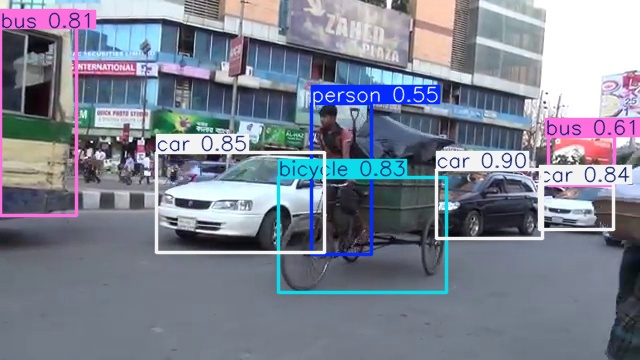

In [72]:
Image.open(location_of_results / "frame_1050.jpg")